# 人脸识别

![face](picture/face.png)

![face2](picture/face2.png)

![face3](picture/face3.png)

![face4](picture/face4.png)

![face5](picture/face5.png)

![face6](picture/face6.png)

In [1]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt

## 基于Haar级联分类器的人脸检测

In [2]:
# 加载定义好的人脸以及眼睛信息匹配信息
# https://github.com/opencv/opencv/tree/4.x/data/haarcascades
face_cascade = cv.CascadeClassifier('./models/haarcascade_frontalface_default.xml')
eye_cascade = cv.CascadeClassifier('./models/haarcascade_eye.xml')

人脸数据的形状(人脸数量，坐标和尺寸)： (12, 4)


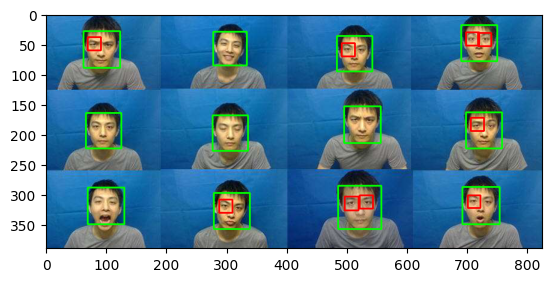

In [3]:
# 加载图像
img = cv.imread('./images/faces.png')
# 转为灰度图
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

# 检测人脸
# scaleFactor=1.3：用于检测不同大小的人脸。值越大，检测速度越快，但可能漏检小脸；值越小（>1），检测更彻底但速度更慢
# minNeighbors=5：控制误检的参数。值越大，检测到的人脸数量越少，但质量越高（减少误检）；值越小，可能返回更多人脸但包含更多误检
faces = face_cascade.detectMultiScale(gray, scaleFactor=1.3, minNeighbors=5)
print("人脸数据的形状(人脸数量，坐标和尺寸)：", faces.shape)

# 遍历人脸
for x, y, w, h in faces:
    # 画人脸区域
    cv.rectangle(img, (x, y), (x + w, y + h), (0, 255, 0), 2)
    
    # 获得人脸区域
    roi_gray = gray[y:y + h, x:x + w]  # 灰度图
    roi_img = img[y:y + h, x:x + w]    # 原图
    
    # 在灰度图的人脸区域检测眼睛
    eyes = eye_cascade.detectMultiScale(roi_gray)
    # 遍历眼睛
    for (ex, ey, ew, eh) in eyes:
        # 在原图的人脸区域画眼睛
        cv.rectangle(roi_img, (ex, ey), (ex + ew, ey + eh), (0, 0, 255), 2)

# 可视化
# cv.imshow('img', img)
# cv.waitKey(0)
# cv.destroyAllWindows()
plt.imshow(img[:, :, ::-1])

In [4]:
def face_detect_return_points(img):
    """
    人脸检测、眼睛检测
    返回人脸和眼睛的坐标点
    """
    # 初始化人脸和眼睛的坐标点
    face_points = []
    eye_points = []

    # 转为灰度图
    gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

    # 创建 CLAHE（对比度受限的自适应直方图均衡化）对象，用于图像增强
    # clipLimit=2.0：值越小，对比度增强越温和；值越大，对比度越强，但可能放大噪声
    # tileGridSize=(8, 8)：分块越小，局部对比度增强越细致，但计算量增大；分块越大，接近全局均衡化效果
    clahe = cv.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    # 执行自适应的直方图均衡
    gray = clahe.apply(gray)

    # 检测人脸
    # scaleFactor=1.3：值越大，检测速度越快，但可能漏检小脸；值越小（>1），检测更彻底但速度更慢
    # minNeighbors=5：值越大，检测到的人脸数量越少，但质量越高（减少误检）；值越小，可能返回更多人脸但包含更多误检
    faces = face_cascade.detectMultiScale(gray, scaleFactor=1.3, minNeighbors=5)
    # 遍历人脸
    for (x, y, w, h) in faces:
        # 添加人脸的坐标点
        face_points.append([x, y, x + w, y + h])
        
        # 获得人脸区域
        roi_gray = gray[y:y + h, x:x + w] 
        
        # 检测眼睛
        eyes = eye_cascade.detectMultiScale(roi_gray)
        # 遍历眼睛
        for (ex, ey, ew, eh) in eyes:
            # 添加眼睛的坐标点
            eye_points.append([ex + x, ey + y, ex + ew + x, ey + eh + y])
            
    # 返回人脸坐标点、眼睛坐标点
    return face_points, eye_points


def draw_rect(img, face_points, eye_points):
    """
    画矩形
    返回画好的图像
    """
    # 画人脸
    for x1, y1, x2, y2 in face_points:
        cv.rectangle(img, (x1, y1), (x2, y2), (255, 0, 0), 2)

    # 画眼睛
    for x1, y1, x2, y2 in eye_points:
        cv.rectangle(img, (x1, y1), (x2, y2), (0, 0, 255), 2)

    return img


def face_detect(img, flag=True):
    """
    人脸检测
    返回 对画矩形函数的调用
    """
    # 定义全局变量：人脸坐标点、眼睛坐标点
    global global_face_points, global_eye_points
    print(f"位置检测：{flag}")
    
    # 可以结合业务的情况，对视频中图像进行间隔的处理（也就是可以不是每个图像都处理）
    if flag is True:
        # 调用函数，进行图像检测，返回人脸坐标点、眼睛坐标点
        face_points, eye_points = face_detect_return_points(img)
        # 赋值给全局变量
        global_face_points = face_points
        global_eye_points = eye_points

    # 返回 对画矩形函数的调用
    return draw_rect(img, global_face_points, global_eye_points)

位置检测：True


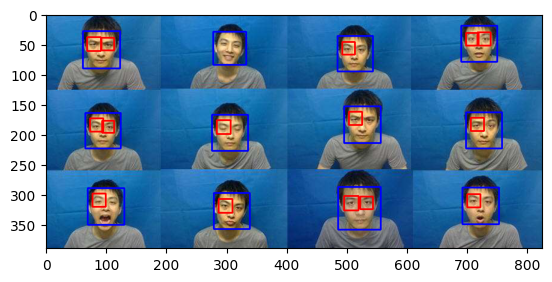

In [5]:
# 加载图像
img = cv.imread('./images/faces.png')

# 可视化（检测到了更多的眼睛）
# cv.imshow('img', face_detect(img))
# cv.waitKey(0)
# cv.destroyAllWindows()
plt.imshow(face_detect(img)[:, :, ::-1])

In [6]:
"""从摄像机获取视频 + 人脸区域提取"""

# 创建一个基于摄像头的视频读取流，给定基于第一个视频设备
capture = cv.VideoCapture(0)

# # 设置摄像头相关参数（但是实际参数会进行稍微的偏移）（可以不设）
# success=capture.set(cv.CAP_PROP_FRAME_WIDTH, 880)
# if success:
#     print("设置宽度成功")
# success=capture.set(cv.CAP_PROP_FRAME_HEIGHT, 480)
# if success:
#     print("设置高度成功")

# # 打印属性
# size = (int(capture.get(cv.CAP_PROP_FRAME_WIDTH)),
#         int(capture.get(cv.CAP_PROP_FRAME_HEIGHT)))
# print(size)

# 遍历获取视频中的图像
# 读取当前时刻的摄像头捕获的图像, 返回为值：True/False, Image/None
success, frame = capture.read()

# 遍历以及等待任意键盘输入
# cv.waitKey(1) == -1：1 表示程序会暂停 1 毫秒，然后继续执行；如果没有按键被按下，返回 -1
while success and cv.waitKey(1) == -1:
    # 将捕获的图像赋值给 img
    img = frame
    
    # 转为灰度图
    gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
    
    # 创建 CLAHE（对比度受限的自适应直方图均衡化）对象，用于图像增强
    # clipLimit=2.0：值越小，对比度增强越温和；值越大，对比度越强，但可能放大噪声
    # tileGridSize=(8, 8)：分块越小，局部对比度增强越细致，但计算量增大；分块越大，接近全局均衡化效果
    clahe = cv.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    # 执行自适应的直方图均衡
    gray = clahe.apply(gray)
    
    # 检测人脸
    # scaleFactor=1.3：值越大，检测速度越快，但可能漏检小脸；值越小（>1），检测更彻底但速度更慢
    # minNeighbors=5：值越大，检测到的人脸数量越少，但质量越高（减少误检）；值越小，可能返回更多人脸但包含更多误检
    faces = face_cascade.detectMultiScale(gray, scaleFactor=1.3, minNeighbors=5)
    # 遍历人脸
    for (x, y, w, h) in faces:
        # 画人脸区域
        cv.rectangle(img, (x, y), (x + w, y + h), (255, 0, 0), 2)

        # 获得人脸区域
        roi_gray = gray[y:y  +h, x:x + w]  # 灰度图
        roi_img = img[y:y + h, x:x + w]    # 原图

        # 在灰度图的人脸区域检测眼睛
        eyes = eye_cascade.detectMultiScale(roi_gray)
        # 遍历眼睛
        for (ex, ey, ew, eh) in eyes:
            # 在原图的人脸区域画眼睛
            cv.rectangle(roi_img, (ex, ey), (ex + ew, ey + eh), (0, 0, 255), 2)
    
    # 显示视频帧
    cv.imshow('frame', img)

    # 读取下一帧的图像
    success, frame = capture.read()

# 释放资源
capture.release()
cv.destroyAllWindows()

OpenCV 初步处理图像，再发给深度学习处理

In [7]:
"""从摄像机获取视频 + 人脸区域提取"""

# 创建一个基于摄像头的视频读取流，给定基于第一个视频设备
capture = cv.VideoCapture(0)

# 遍历获取视频中的图像
# 读取当前时刻的摄像头捕获的图像，返回为值：True/False, Image/None
success, frame = capture.read()

# 遍历以及等待任意键盘输入
# cv.waitKey(1) == -1：1 表示程序会暂停 1 毫秒，然后继续执行；如果没有按键被按下，返回 -1
while success and cv.waitKey(1) == -1:
    # 将捕获的图像赋值给 img
    img = frame
    
    # 转为灰度图
    gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

    # 人脸检测
    # scaleFactor=1.3：值越大，检测速度越快，但可能漏检小脸；值越小（>1），检测更彻底但速度更慢
    # minNeighbors=5：值越大，检测到的人脸数量越少，但质量越高（减少误检）；值越小，可能返回更多人脸但包含更多误检
    faces = face_cascade.detectMultiScale(gray, scaleFactor=1.3, minNeighbors=5)
    if len(faces) > 0:
        # NOTE: 检测出人脸后，直接将人脸发送给服务器进行业务逻辑 + 模型预测等相关处理
        pass
    
    # 显示视频帧
    cv.imshow('frame', img)

    # 读取下一帧的图像
    success, frame = capture.read()

# 释放资源
capture.release()
cv.destroyAllWindows()